1. Objectives & Learning Outcomes

By the end of this lab, you will be able to:

Load and explore raster data using Python.

Perform map algebra operations on raster datasets.

Apply raster analysis techniques (e.g., reclassification, masking).

Automate repetitive raster workflows by writing functions.

Reflect on how coding workflows translate to real-world geospatial analysis.

Setup & Dataset

We’ll generate synthetic rasters (so you don’t need to download anything). Later, you can swap in real rasters (e.g., DEM, NDVI).

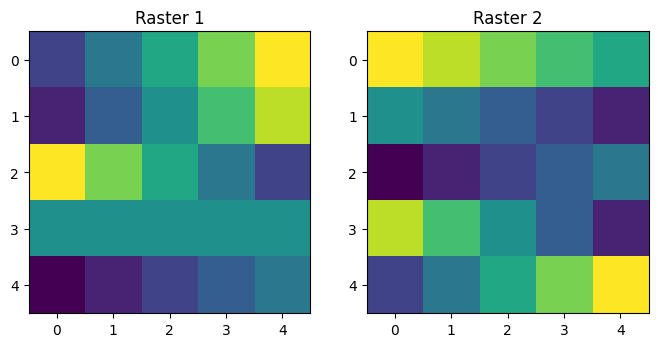

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create two synthetic 5x5 rasters
raster1 = np.array([
    [2, 4, 6, 8, 10],
    [1, 3, 5, 7, 9],
    [10, 8, 6, 4, 2],
    [5, 5, 5, 5, 5],
    [0, 1, 2, 3, 4]
])

raster2 = np.array([
    [10, 9, 8, 7, 6],
    [5, 4, 3, 2, 1],
    [0, 1, 2, 3, 4],
    [9, 7, 5, 3, 1],
    [2, 4, 6, 8, 10]
])

# Quick visualization
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(raster1, cmap="viridis")
axes[0].set_title("Raster 1")
axes[1].imshow(raster2, cmap="viridis")
axes[1].set_title("Raster 2")
plt.show()


Map Algebra Operations

Addition & Subtraction

In [ ]:
added = raster1 + raster2
subtracted = raster1 - raster2

print("Added Raster:\n", added)
print("\nSubtracted Raster:\n", subtracted)


Added Raster:
 [[12 13 14 15 16]
 [ 6  7  8  9 10]
 [10  9  8  7  6]
 [14 12 10  8  6]
 [ 2  5  8 11 14]]

Subtracted Raster:
 [[-8 -5 -2  1  4]
 [-4 -1  2  5  8]
 [10  7  4  1 -2]
 [-4 -2  0  2  4]
 [-2 -3 -4 -5 -6]]


Write a function that performs all arithmetic functions on a raster?

In [ ]:
def raster_arithmetic(raster1, raster2):
  added = raster1 + raster2
  subtracted = raster1 - raster2
  multiplied = raster1 * raster2
  divided = raster1 / raster2
  return added, subtracted, multiplied, divided

added_raster, subtracted_raster, multiplied_raster, divided_raster = raster_arithmetic(raster1, raster2)

print("Added Raster:\n", added_raster)
print("\nSubtracted Raster:\n", subtracted_raster)
print("\nMultiplied Raster:\n", multiplied_raster)
print("\nDivided Raster:\n", divided_raster)

Added Raster:
 [[12 13 14 15 16]
 [ 6  7  8  9 10]
 [10  9  8  7  6]
 [14 12 10  8  6]
 [ 2  5  8 11 14]]

Subtracted Raster:
 [[-8 -5 -2  1  4]
 [-4 -1  2  5  8]
 [10  7  4  1 -2]
 [-4 -2  0  2  4]
 [-2 -3 -4 -5 -6]]

Multiplied Raster:
 [[20 36 48 56 60]
 [ 5 12 15 14  9]
 [ 0  8 12 12  8]
 [45 35 25 15  5]
 [ 0  4 12 24 40]]

Divided Raster:
 [[0.2        0.44444444 0.75       1.14285714 1.66666667]
 [0.2        0.75       1.66666667 3.5        9.        ]
 [       inf 8.         3.         1.33333333 0.5       ]
 [0.55555556 0.71428571 1.         1.66666667 5.        ]
 [0.         0.25       0.33333333 0.375      0.4       ]]


/tmp/ipython-input-2976111041.py:5: RuntimeWarning: divide by zero encountered in divide
  divided = raster1 / raster2


Conditional Classification
(Classify values > 5 as 1, else 0)

In [ ]:
classified = np.where(raster1 > 5, 1, 0)
print("\nClassified Raster (values > 5 = 1):\n", classified)


Classified Raster (values > 5 = 1):
 [[0 0 1 1 1]
 [0 0 0 1 1]
 [1 1 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


▶ Write a function that prints out the values of a raster that are above 7 and below 3.

In [ ]:
def print_values_above_7_below_3(raster):
  """Prints values in a raster that are above 7 or below 3."""
  above_7 = raster[raster > 7]
  below_3 = raster[raster < 3]
  print("Values above 7:", above_7)
  print("Values below 3:", below_3)

print_values_above_7_below_3(raster1)

Values above 7: [ 8 10  9 10  8]
Values below 3: [2 1 2 0 1 2]


Visualization

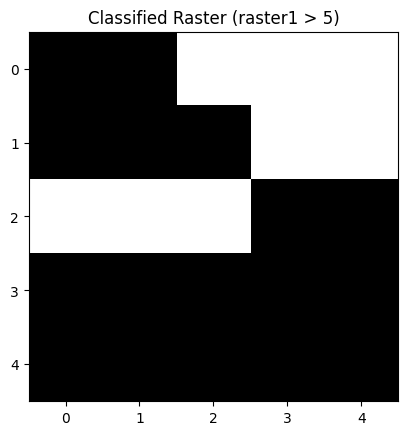

In [ ]:
plt.imshow(classified, cmap="gray")
plt.title("Classified Raster (raster1 > 5)")
plt.show()

▶ Write a function that plots raster files. (Bonus points if you can include a way to accept user input for what range of values they want to have show and what color they want to use for cmap).

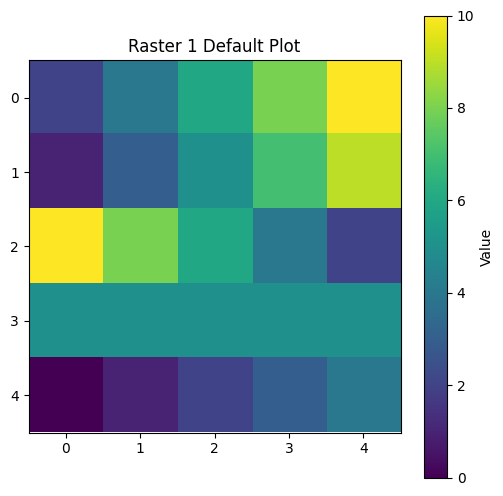

In [ ]:
import matplotlib.pyplot as plt

def plot_raster(raster, title="Raster Plot", cmap="viridis", vmin=None, vmax=None):
  plt.figure(figsize=(6, 6))
  plt.imshow(raster, cmap=cmap, vmin=vmin, vmax=vmax)
  plt.title(title)
  plt.colorbar(label="Value")
  plt.show()

plot_raster(raster1, title="Raster 1 Default Plot")

Automating with Functions

Instead of repeating the same steps, wrap them into a function (everything above).


Raster 1 - Values above 7: [ 8 10  9 10  8]
Raster 1 - Values below 3: [2 1 2 0 1 2]

Added Raster:
 [[12 13 14 15 16]
 [ 6  7  8  9 10]
 [10  9  8  7  6]
 [14 12 10  8  6]
 [ 2  5  8 11 14]]

Subtracted Raster:
 [[-8 -5 -2  1  4]
 [-4 -1  2  5  8]
 [10  7  4  1 -2]
 [-4 -2  0  2  4]
 [-2 -3 -4 -5 -6]]

Multiplied Raster:
 [[20 36 48 56 60]
 [ 5 12 15 14  9]
 [ 0  8 12 12  8]
 [45 35 25 15  5]
 [ 0  4 12 24 40]]

Divided Raster:
 [[0.2        0.44444444 0.75       1.14285714 1.66666667]
 [0.2        0.75       1.66666667 3.5        9.        ]
 [       inf 8.         3.         1.33333333 0.5       ]
 [0.55555556 0.71428571 1.         1.66666667 5.        ]
 [0.         0.25       0.33333333 0.375      0.4       ]]

Classified Raster (raster1 > 5 = 1):
 [[0 0 1 1 1]
 [0 0 0 1 1]
 [1 1 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


/tmp/ipython-input-4134419205.py:9: RuntimeWarning: divide by zero encountered in divide
  divided = raster1 / raster2


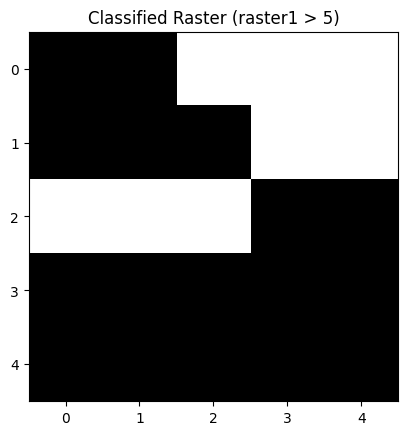

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_rasters(raster1, raster2, threshold=5):

  added = raster1 + raster2
  subtracted = raster1 - raster2
  multiplied = raster1 * raster2
  divided = raster1 / raster2

  classified = np.where(raster1 > threshold, 1, 0)

  print("\nRaster 1 - Values above 7:", raster1[raster1 > 7])
  print("Raster 1 - Values below 3:", raster1[raster1 < 3])

  return added, subtracted, multiplied, divided, classified

raster1 = np.array([
    [2, 4, 6, 8, 10],
    [1, 3, 5, 7, 9],
    [10, 8, 6, 4, 2],
    [5, 5, 5, 5, 5],
    [0, 1, 2, 3, 4]
])

raster2 = np.array([
    [10, 9, 8, 7, 6],
    [5, 4, 3, 2, 1],
    [0, 1, 2, 3, 4],
    [9, 7, 5, 3, 1],
    [2, 4, 6, 8, 10]
])



added_raster, subtracted_raster, multiplied_raster, divided_raster, classified_raster = analyze_rasters(raster1, raster2)

print("\nAdded Raster:\n", added_raster)
print("\nSubtracted Raster:\n", subtracted_raster)
print("\nMultiplied Raster:\n", multiplied_raster)
print("\nDivided Raster:\n", divided_raster)
print("\nClassified Raster (raster1 > 5 = 1):\n", classified_raster)

plt.imshow(classified_raster, cmap="gray")
plt.title("Classified Raster (raster1 > 5)")
plt.show()

Reflection Activity

Write a short reflection (8–10 sentences) responding to these prompts:

How do the addition and subtraction operations relate to real-world raster applications (e.g., change detection, rainfall difference, NDVI)?

Why is classification important in raster analysis (e.g., land cover mapping, hazard zones)?

How does wrapping raster operations into a function improve reproducibility and workflow efficiency?

If you were given 100 rasters (instead of 2), how would automation help you scale your analysis?

What surprised you most about how Python handles raster math?

Addition and Subtraction are the best when it comes to real-world raster applications becasue it becomes easier to compare different raster datasets. An example could be looking rainfall in a certain region in two different time periods, using addition and subtraction can be useful to compare the difference between the two time periods. Classification is important in raster analysis because it takes the raw data and makes it easier to work with and to analyze. A good example would be with land cover, taking raw data and giving it a classification allows us to compare changes by seeing what classifications are changing from dataset to dataset. Automation would help to easily run multiple rasters without having to retype and rerun code again and again. Python runs math a lot faster than I originally expected. I thought it would take longer to run each pice of code, but instead, it barely took any time at all.